In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import yaml

from pmt_analysis import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# Read Data

In [2]:
data_dir = Path("data/calibLED/260611/segmented_wTrig")
# files = sorted(data_dir.glob("southCovered_525MHz_fewHours_trig1800uV-1.h5")) 
files = sorted(data_dir.glob("southCovered_525MHz_fewHours_trig1800uV-*.h5")) 
# files = sorted(data_dir.glob("southCovered_525MHz_fewHours_trig31790uV.h5")) 

for file in files:
    print(file)
print(f"Number of files: {len(files)}")

data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-1.h5
data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-10.h5
data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-2.h5
data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-3.h5
data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-4.h5
data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-5.h5
data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-6.h5
data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-7.h5
data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-8.h5
data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-9.h5
Number of files: 10


In [3]:
maxEvts = 1000 # small sample size
time_s, voltage_sample_V, metadata = read_keysight_h5_direct(
    files[0],
    segment_numbers=range(maxEvts),
)
time_ns, voltage_sample_mV, adc_step_mV, units_time, units_voltage = standard_units(
    time_s,
    voltage_sample_V,
    metadata,
)

print(f"Sample waveforms: {voltage_sample_mV.shape}")
print(f"Time range: {time_ns[0]:.3f} to {time_ns[-1]:.3f} ns")
print(f"Sampling step: {np.median(np.diff(time_ns)):.5f} ns")
print(f"ADC step: {adc_step_mV:.6f} mV")

Sample waveforms: (999, 1000)
Time range: -27.275 to 35.163 ns
Sampling step: 0.06250 ns
ADC step: 0.001276 mV


# Set Config. Values

In [4]:
config_name = 'DC_525MHz_fewHours_trig1800uV'
# default config
with open('config_default.yml', 'r') as file:
    # Load and parse the YAML content safely
    config = yaml.safe_load(file)[config_name]['general']

## config
baseline_window_ns = (time_ns[0], time_ns[0]+config['baseline_window_width_ns'])
integration_window_ns  = (config['integration_window_ns'][0], config['integration_window_ns'][1])
peak_search_window_ns  = (config['peak_search_window_ns'][0], config['peak_search_window_ns'][1])
allowed_peak_window_ns = (config['allowed_peak_window_ns'][0], config['allowed_peak_window_ns'][1])
global_peak_voltage_max_mV = None if (config['global_peak_voltage_max_mV']=='None') else (config['global_peak_voltage_max_mV'])
out_of_window_peak_voltage_max_mV = config['out_of_window_peak_voltage_max_mV']

config



{'baseline_window_width_ns': 20,
 'integration_window_ns': [-1, 9],
 'peak_search_window_ns': [-1, 9],
 'global_peak_voltage_max_mV': 'None',
 'out_of_window_peak_voltage_max_mV': -1.8,
 'allowed_peak_window_ns': [-1, 9]}

In [5]:
### not in config
threshold_mV = 0. # threshold to compute mean waveform (if no cut, the baseline dominates)
rise_low_fraction = 0.1
rise_high_fraction = 0.9
show_residual_errorbars = True

# Selection

- remove peaks that are clearely out of time (+ small threshold to define "a peak")

In [6]:
selection = collect_peak_time_voltage_selection(
    files,
    baseline_window_ns=baseline_window_ns,
    peak_window_ns=allowed_peak_window_ns,
    global_peak_voltage_max_mV=global_peak_voltage_max_mV, # cut all events with peak higher below a cut (i.e. remove small waveforms)
    out_of_window_peak_voltage_max_mV=out_of_window_peak_voltage_max_mV,
    peak_search_window_ns=peak_search_window_ns,
    selection_mask=None,
    chunk_size=4096,
    low_fraction=rise_low_fraction,
    high_fraction=rise_high_fraction,
)

print(f'selection efficiency = {selection['efficiency']*100} %  ({selection['n_kept']} / {selection['n_total']})')
print(f'events whose peak passes the “real pulse” voltage threshold (full time window) = {np.sum( selection['real_peak_mask'] )}')
print(f'events whose measured peak time is inside peak_window_ns    = {np.sum( selection['in_peak_window_mask'] )}')
mask = (selection['real_peak_mask']==True) & (selection['in_peak_window_mask']==True)
real_peaks_sel = selection['peak_value_mV'][mask]
print(f'number of events with a "real peak" inside the selected peak widnow = {real_peaks_sel.shape[0]}  ({real_peaks_sel.shape[0]*100 / selection['n_total']:.2f} %)')

# for k in selection.keys():
#     print(k)

selection efficiency = 100.0 %  (316820 / 316820)
events whose peak passes the “real pulse” voltage threshold (full time window) = 67961
events whose measured peak time is inside peak_window_ns    = 316820
number of events with a "real peak" inside the selected peak widnow = 67961  (21.45 %)


In [7]:
summary = summarize_waveforms(
    files,
    baseline_window_ns=baseline_window_ns,
    chunk_size=4096,
    selection_mask=selection["keep_mask"]
)

print(f"Baseline residual is centered near zero?: {np.mean(summary['baseline_check_mV']):.3e} mV")

# for k in summary.keys():
#     print(k)

Baseline residual is centered near zero?: 1.177e-09 mV


# Charge

In [8]:
selected_charges_by_window = compute_charges_for_windows(
    files,
    baseline_window_ns=baseline_window_ns,
    integration_windows_ns=[integration_window_ns],
    selection_mask=selection["keep_mask"],
    chunk_size=4096,
)
charge_mV_ns = selected_charges_by_window[integration_window_ns]

print(f"Selected events: {selection['n_kept']} / {selection['n_total']} ({selection['efficiency']:.3%})")

Selected events: 316820 / 316820 (100.000%)


# Fits

In [9]:
with open('config_default.yml', 'r') as file:
    # Load and parse the YAML content safely
    fit_general = yaml.safe_load(file)[config_name]['fit_general']

fit_range = (fit_general['fit_range'][0], fit_general['fit_range'][1])
nbins = fit_general['fit_nbins']

fit_general

{'fit_range': [-6.0, 150.0], 'fit_nbins': 250}

## Simple Poisson model

,parameter,initial,lower_bound,upper_bound,fixed,fit_value,fit_error
0,n_total,316820.00,158410.0000,633640.0,False,286576.773737,535.402987
1,mu_pe,0.03,0.0010,5.0,False,0.007279,0.000185
2,q0_mV_ns,0.80,-6.0000,10.0,False,0.835387,0.001658
3,sigma0_mV_ns,0.90,0.0001,50.0,False,0.874670,0.001090
4,q1_mV_ns,12.00,12.0000,12.0,True,12.000000,0.000000
5,sigma1_mV_ns,10.00,10.0000,10.0,True,10.000000,0.000000


chi2/ndof: 122.452


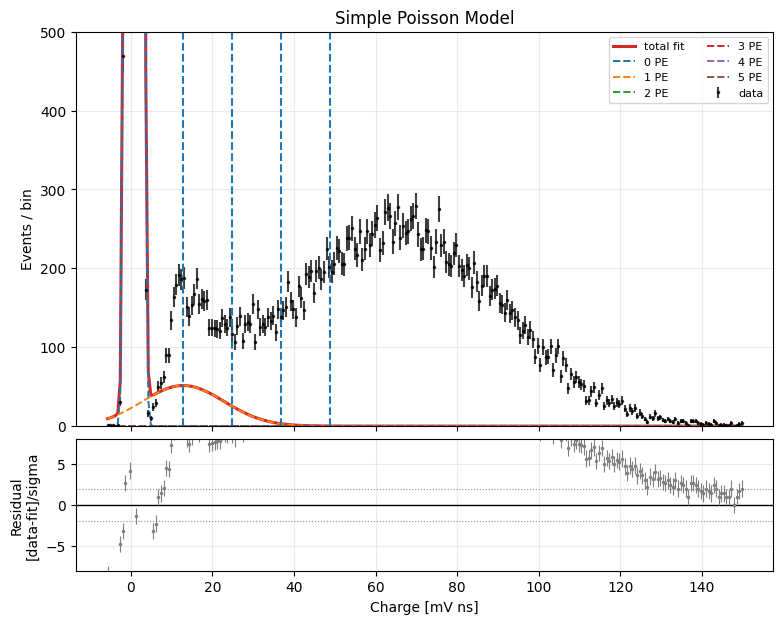

In [10]:
maxPE = 5

poisson_fit_p0 = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    # Set isFixed=True to hold a parameter at the initial value during the fit.
    "n_total": [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 2.0 * len(charge_mV_ns), False],
    "q0_mV_ns":     [0.8, -6.0, 10.0, False],
    "sigma0_mV_ns": [0.9, 1e-4, 50.0, False],
    "q1_mV_ns":     [12.0, 5.0, 20.0, True],
    "sigma1_mV_ns": [10.0, 0.2, 40.0, True],
    "mu_pe":        [0.03, 0.001, 5.0, False],
}

fit_kwargs = dict(
    fit_range=fit_range,
    bins=nbins,
    max_pe=maxPE,
    p0=poisson_fit_p0,
)

fit_all = fit_spe_spectrum(charge_mV_ns, **fit_kwargs)

table = fit_result_table(fit_all)
display(table)
# print_fit_result_table(fit_all)
print(f"chi2/ndof: {fit_all['chi2'] / fit_all['ndof']:.3f}")

fig, ax, ax_resid = plot_fit_result(
    fit_all,
    title="Simple Poisson Model",
    logscale=False,
    ylims= (0, 500),
)

# ax.axvline( 5, ls="--")

q0_mV_ns = table.set_index("parameter").loc["q0_mV_ns", "fit_value"]
q1_mV_ns = table.set_index("parameter").loc["q1_mV_ns", "fit_value"]
for i in range(1, maxPE):
    ax.axvline(q0_mV_ns + i*q1_mV_ns, ls="--")




## Poisson with asymmetric widths

,parameter,initial,lower_bound,upper_bound,fixed,fit_value,fit_error
0,n_pedestal,30000.0,0.00,633640.0,False,2.848051e+05,533.976859
1,q0_mV_ns,0.8,-10.00,20.0,False,8.342532e-01,0.001656
2,sigma0_mV_ns,0.8,0.05,30.0,False,8.773260e-01,0.001085
3,q1_mV_ns,15.0,5.00,20.0,False,2.000000e+01,0.157791
4,sigma1_left_mV_ns,8.0,3.00,40.0,False,8.027081e+00,0.176615
5,sigma1_right_mV_ns,8.0,3.00,40.0,False,1.564030e+01,0.161431
6,n_1pe,79205.0,0.00,633640.0,False,6.839252e+03,148.990860
7,n_2pe,15841.0,0.00,633640.0,False,8.188453e-15,396.944251
8,n_3pe,3168.2,0.00,633640.0,False,2.137295e+04,382.945199
9,constant_per_bin,0.1,0.00,inf,False,2.854278e-25,0.308173


chi2/ndof: 15.108


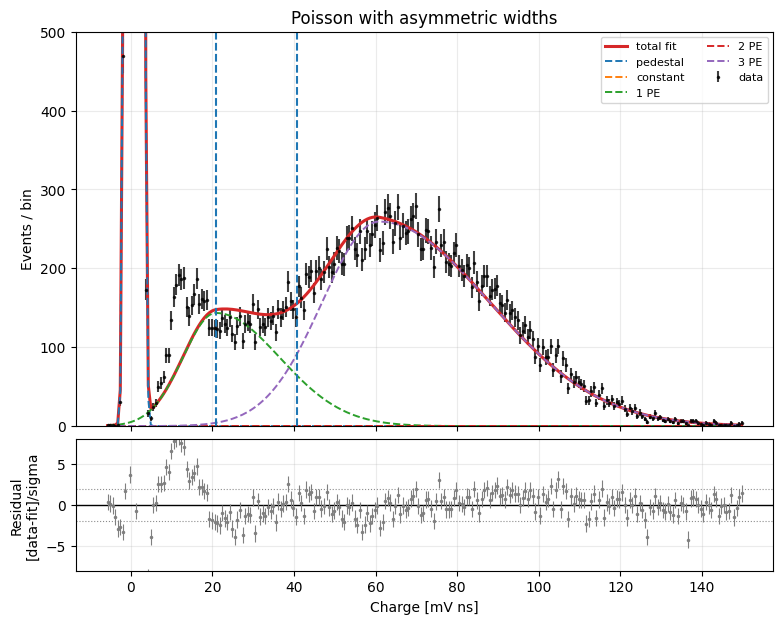

In [11]:
maxPE = 3

free_fit_p0 = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed].
    # "n_pedestal": [0.5 * len(fit_charge), 0.0, 2.0 * len(fit_charge), False],
    "n_pedestal": [30000, 0.0, 2.0 * len(charge_mV_ns), False],
    "q0_mV_ns": [0.8, -10.0, 20.0, False],
    "sigma0_mV_ns": [0.8, 0.05, 30.0, False],
    "q1_mV_ns": [15.0, 5.0, 20.0, False],
    "sigma1_left_mV_ns": [8.0, 3., 40.0, False],
    "sigma1_right_mV_ns": [8.0, 3., 40, False],
    "n_1pe": [0.25 * len(charge_mV_ns), 0.0, 2.0 * len(charge_mV_ns), False],
    "n_2pe": [0.05 * len(charge_mV_ns), 0.0, 2.0 * len(charge_mV_ns), False],
    "n_3pe": [0.01 * len(charge_mV_ns), 0.0, 2.0 * len(charge_mV_ns), False],
    "constant_per_bin": [0.1, 0.0, np.inf, False],
}

fit_kwargs = dict(
    fit_range=fit_range,
    bins=nbins,
    max_pe=maxPE,
    p0=free_fit_p0,
)

fit_all = fit_free_spe_spectrum(charge_mV_ns, **fit_kwargs)

table = fit_result_table(fit_all)
display(table)
print(f"chi2/ndof: {fit_all['chi2'] / fit_all['ndof']:.3f}")

fig, ax, ax_resid = plot_fit_result(
    fit_all,
    title="Poisson with asymmetric widths",
    logscale=False,
    ylims= (0, 500),
)

q0_mV_ns = table.set_index("parameter").loc["q0_mV_ns", "fit_value"]
q1_mV_ns = table.set_index("parameter").loc["q1_mV_ns", "fit_value"]
for i in range(1, maxPE):
    ax.axvline(q0_mV_ns + i*q1_mV_ns, ls="--")


## Bellamy

,parameter,initial,lower_bound,upper_bound,fixed,fit_value,fit_error
0,n_total,316820.00,158410.0000,633640.0,False,320137.478699,4.669969e-09
1,mu_pe,0.03,0.0010,5.0,False,0.016944,2.683579e-04
2,q0_mV_ns,0.80,-6.0000,10.0,False,0.832502,1.685499e-03
3,sigma0_mV_ns,0.90,0.0001,50.0,False,0.878035,1.101323e-03
4,q1_mV_ns,12.00,5.0000,20.0,False,16.846899,1.206176e-01
5,sigma1_mV_ns,10.00,0.2000,40.0,False,6.244863,1.035260e-01
6,w,0.03,0.0000,1.0,False,0.111248,1.682170e-03
7,alpha,-1.00,-10.0000,10.0,False,-1.000000,0.000000e+00


chi2/ndof: 111.933


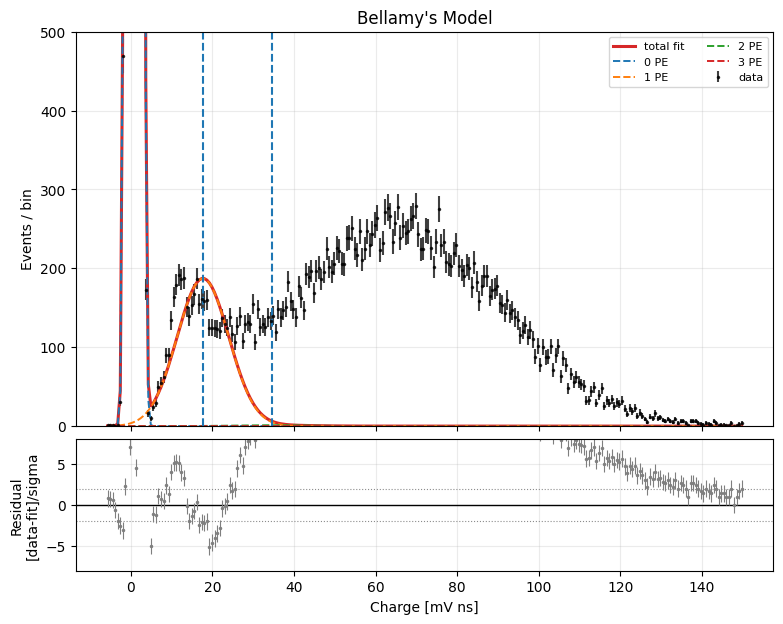

In [12]:
maxPE = 3

bellamy_fit_p0 = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    # Set isFixed=True to hold a parameter at the initial value during the fit.
    "n_total":      [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 2.0 * len(charge_mV_ns), False],
    "q0_mV_ns":     [0.8, -6.0, 10.0, False],
    "sigma0_mV_ns": [0.9, 1e-4, 50.0, False],
    "q1_mV_ns":     [12.0, 5.0, 20.0, False],
    "sigma1_mV_ns": [10.0, 0.2, 40.0, False],
    "mu_pe":        [0.03, 0.001, 5.0, False],
    "w":     [0.03, 0., 1., False],
    "alpha": [-1., -10., 10., False],
}

fit_kwargs = dict(
    fit_range=fit_range,
    bins=nbins,
    max_pe=maxPE,
    p0=bellamy_fit_p0,
)

fit_all = fit_bellamy_spe_spectrum(charge_mV_ns, **fit_kwargs)

table = fit_result_table(fit_all)
display(table)
print(f"chi2/ndof: {fit_all['chi2'] / fit_all['ndof']:.3f}")

fig, ax, ax_resid = plot_fit_result(
    fit_all,
    title="Bellamy's Model",
    logscale=False,
    ylims= (0, 500),
)

q0_mV_ns = table.set_index("parameter").loc["q0_mV_ns", "fit_value"]
q1_mV_ns = table.set_index("parameter").loc["q1_mV_ns", "fit_value"]
for i in range(1, maxPE):
    ax.axvline(q0_mV_ns + i*q1_mV_ns, ls="--")


## Two-paths

Check formula

,parameter,initial,lower_bound,upper_bound,fixed,fit_value,fit_error
0,n_total,316820.00,158410.0000,633640.0,False,313082.422923,559.844909
1,mu_pe,0.03,0.0010,5.0,False,0.093332,0.000560
2,q0_mV_ns,0.80,-6.0000,10.0,False,0.834495,0.001654
3,sigma0_mV_ns,0.90,0.0001,50.0,False,0.876898,0.001081
4,g1_mV_ns,12.00,5.0000,20.0,False,15.232957,0.142205
5,sigma_g1_mV_ns,10.00,0.2000,40.0,False,5.071735,0.130714
6,g2_mV_ns,20.00,0.0000,150.0,False,62.969205,0.206093
7,sigma_g2_mV_ns,10.00,0.0000,150.0,False,23.285229,0.167572
8,alpha,0.50,0.0000,1.0,False,0.884824,0.003048


chi2/ndof: 15.970


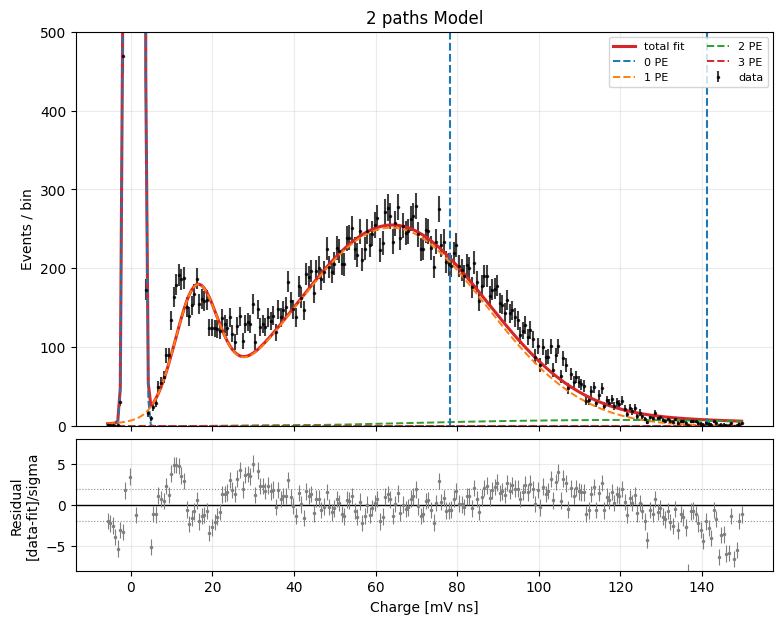

In [13]:
maxPE = 3

TwoPaths_fit_p0 = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    # Set isFixed=True to hold a parameter at the initial value during the fit.
    "n_total":        [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 2.0 * len(charge_mV_ns), False],
    "mu_pe":          [0.03, 0.001, 5.0, False],
    "q0_mV_ns":       [0.8, -6.0, 10.0, False],
    "sigma0_mV_ns":   [0.9, 1e-4, 50.0, False],
    "g1_mV_ns":       [12.0, 5.0, 20.0, False],
    "sigma_g1_mV_ns":   [10.0, 0.2, 40.0, False],
    "g2_mV_ns":       [20., 0., 150., False],
    "sigma_g2_mV_ns": [10, 0., 150, False],
    "alpha":          [0.5, 0., 1., False],
}

fit_kwargs = dict(
    fit_range=fit_range,
    bins=nbins,
    max_pe=maxPE,
    p0=TwoPaths_fit_p0,
)

fit_all = fit_dynode_spe_spectrum(charge_mV_ns, **fit_kwargs)

table = fit_result_table(fit_all)
display(table)
print(f"chi2/ndof: {fit_all['chi2'] / fit_all['ndof']:.3f}")

fig, ax, ax_resid = plot_fit_result(
    fit_all,
    title="2 paths Model",
    logscale=False,
    ylims= (0, 500),
)

q0_mV_ns = table.set_index("parameter").loc["g1_mV_ns", "fit_value"]
q1_mV_ns = table.set_index("parameter").loc["g2_mV_ns", "fit_value"]
for i in range(1, maxPE):
    ax.axvline(q0_mV_ns + i*q1_mV_ns, ls="--")


## Back-scattering SPE model

Model from Angelino et al. arXiv:2604.02826v2, Eq. 2.23. The 2PE and 3PE fractions are fixed to zero here because this is a dark-count spectrum; unfix them for light/LED data.


,parameter,initial,lower_bound,upper_bound,fixed,fit_value,fit_error
0,n_total,316820.00,158410.0000,633640.0,False,158410.000000,183722.373111
1,q0_mV_ns,0.80,-6.0000,10.0,False,-1.943777,3.201157
2,g1_first_dynode,12.00,5.0000,30.0,False,13.063552,3.396571
3,f_mV_ns,1.00,0.1000,5.0,False,4.999986,1.398933
4,r,0.50,0.0000,2.0,False,1.034333,0.301839
5,sigma_ped_mV_ns,0.90,0.0001,20.0,False,0.000100,1.437784
6,eta,0.25,0.0000,0.8,False,0.008662,0.014013
7,a_gamma1dy,0.00,0.0000,0.0,True,0.000000,0.000000
8,a_exp,0.05,0.0000,0.5,False,0.500000,0.579612
9,alpha_exp_mV_ns,2.00,0.0500,20.0,False,1.380538,0.003454


chi2/ndof: 1797.451


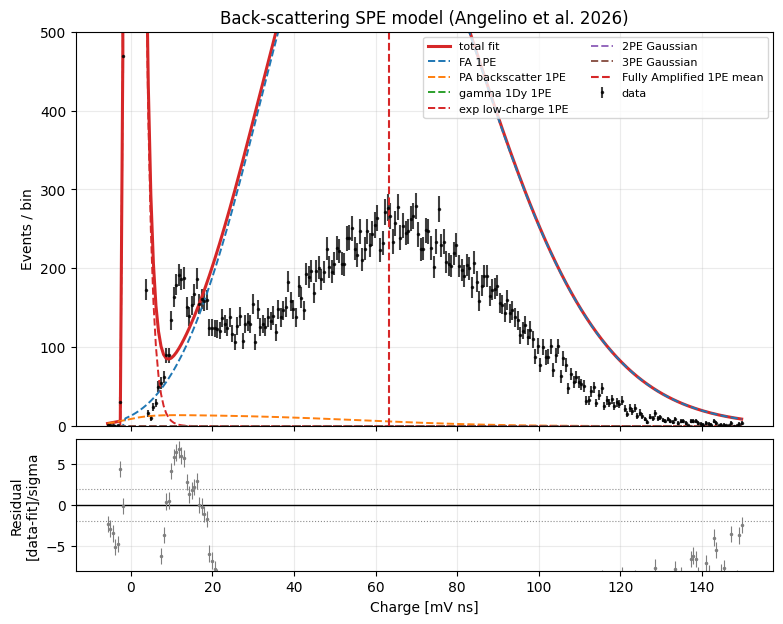

In [14]:
maxMultiPE = 3

backscatter_fit_p0 = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    # g1_first_dynode is dimensionless. f_mV_ns converts one first-dynode electron
    # into charge units, so the fully amplified 1PE mean is q0 + g1_first_dynode*f_mV_ns.
    "n_total":          [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 2.0 * len(charge_mV_ns), False],
    "q0_mV_ns":         [0.8, -6.0, 10.0, False],
    "g1_first_dynode":  [12.0, 5.0, 30.0, False],
    "f_mV_ns":          [1.0, 0.1, 5.0, False],
    "r":                [0.5, 0.0, 2.0, False],
    "sigma_ped_mV_ns":  [0.9, 1e-4, 20.0, False],
    "eta":              [0.25, 0.0, 0.8, False],
    "a_gamma1dy":       [0.0, 0.0, 0.3, True], # True
    "a_exp":            [0.05, 0.0, 0.5, False],
    "alpha_exp_mV_ns":  [2.0, 0.05, 20.0, False],
    "zeta":             [1.2, 0.2, 5.0, True], # 
    "a_2pe":            [0.0, 0.0, 0.5, True], #
    "a_3pe":            [0.0, 0.0, 0.5, True], #
}

fit_kwargs = dict(
    fit_range=fit_range,
    bins=nbins,
    max_multi_pe=maxMultiPE,
    p0=backscatter_fit_p0,
)

fit_all = fit_backscatter_spe_spectrum(charge_mV_ns, **fit_kwargs)

table = fit_result_table(fit_all)
display(table)
print(f"chi2/ndof: {fit_all['chi2'] / fit_all['ndof']:.3f}")

fig, ax, ax_resid = plot_fit_result(
    fit_all,
    title="Back-scattering SPE model (Angelino et al. 2026)",
    logscale=False,
    ylims=(0, 500),
)

params = table.set_index("parameter")["fit_value"]
q0_mV_ns = params["q0_mV_ns"]
g1_first_dynode = params["g1_first_dynode"]
f_mV_ns = params["f_mV_ns"]
ax.axvline(q0_mV_ns + g1_first_dynode * f_mV_ns, ls="--", color="tab:red", label="Fully Amplified 1PE mean")
ax.legend(ncol=2, fontsize=8);
